In [3]:
from sklearn.datasets import load_breast_cancer
df=load_breast_cancer(as_frame=True).frame

In [4]:
import pandas as pd
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

In [6]:
df.dtypes

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

In [7]:
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [8]:
df.shape

(569, 31)

In [9]:
from sklearn.model_selection import train_test_split
x=df.drop(columns='target', axis=1).values
y=df['target'].values


In [10]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=42)
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [11]:
from sklearn.linear_model import LogisticRegression
log_reg=LogisticRegression()
log_reg.fit(x_train, y_train)
y_pred_log=log_reg.predict(x_test)

In [12]:
from sklearn.ensemble import RandomForestClassifier
rf_clf=RandomForestClassifier(random_state=42)
rf_clf.fit(x_train, y_train)
y_pred_rf=rf_clf.predict(x_test)

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def evaluate_model(y_true, y_pred):
    accuracy=accuracy_score(y_true, y_pred)
    precision=precision_score(y_true, y_pred)
    recall=recall_score(y_true, y_pred)
    f1=f1_score(y_true, y_pred)
    return {
        'accuracy': accuracy,
        'precision': precision, 
        'recall': recall,
        'f1_score': f1
    }

In [14]:
evaluate_model(y_test, y_pred_log)


{'accuracy': 0.9736842105263158,
 'precision': 0.9722222222222222,
 'recall': 0.9859154929577465,
 'f1_score': 0.9790209790209791}

In [15]:
evaluate_model(y_test, y_pred_rf)

{'accuracy': 0.9649122807017544,
 'precision': 0.958904109589041,
 'recall': 0.9859154929577465,
 'f1_score': 0.9722222222222222}

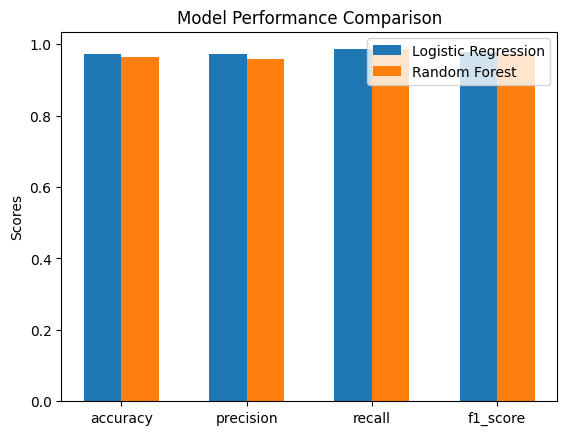

In [37]:
import matplotlib.pyplot as plt
import numpy as np
log_reg_metrics=evaluate_model(y_test, y_pred_log)
rf_clf_metrics=evaluate_model(y_test, y_pred_rf)
labels=list(log_reg_metrics.keys())
x=np.arange(len(labels))
width=0.30
plt.bar(x-width/2, log_reg_metrics.values(), width, label='Logistic Regression')
plt.bar(x+width/2, rf_clf_metrics.values(), width, label='Random Forest')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()


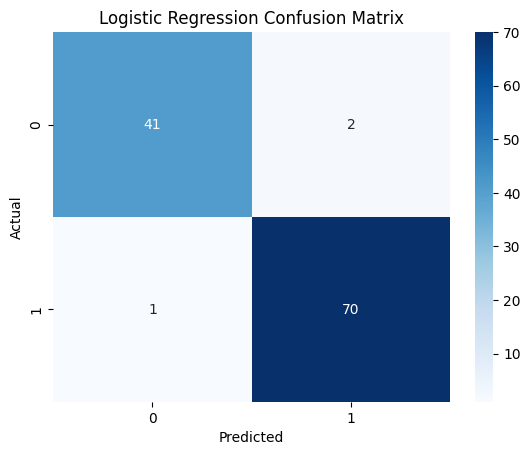

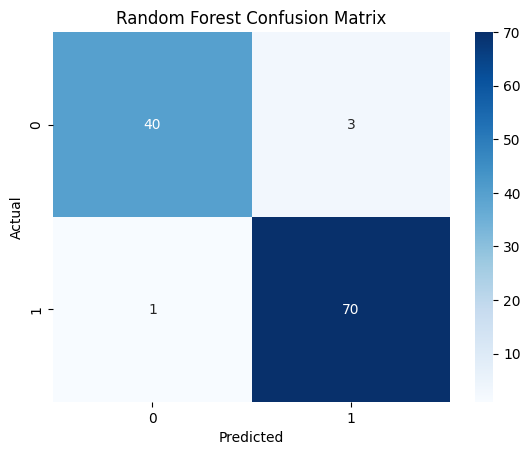

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm=confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
plot_confusion_matrix(y_test, y_pred_log, 'Logistic Regression Confusion Matrix')
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest Confusion Matrix')

In [19]:
from sklearn.metrics import classification_report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))
print('Random Forest Classification Report:')
print(classification_report(y_test, y_pred_rf))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



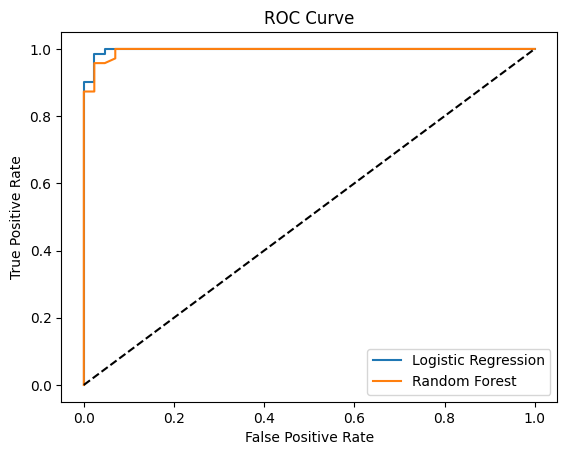

In [29]:
from sklearn.metrics import roc_auc_score, roc_curve
y_prob_log=log_reg.predict_proba(x_test)[:, 1]
y_prob_rf=rf_clf.predict_proba(x_test)[:, 1]
fpr_log, tpr_log, _=roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _=roc_curve(y_test, y_prob_rf)
plt.plot(fpr_log, tpr_log, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [31]:
roc_auc_score(y_test, y_prob_log), roc_auc_score(y_test, y_prob_rf)

(0.99737962659679, 0.995250573206682)

In [28]:
x_test.shape

(114, 30)